In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
train = pd.read_csv("train.csv")

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train.shape

(42000, 785)

In [6]:
train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [10]:
X = train.drop("label",axis=1)
Y = train["label"]


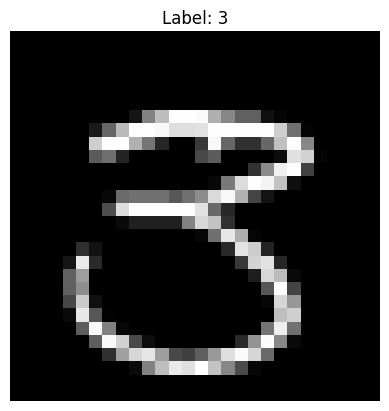

In [18]:
image = X.iloc[7].values.reshape(28,28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {Y.iloc[7]}")
plt.axis("off")
plt.show()

In [19]:
X = X.to_numpy()
Y =Y.to_numpy()

In [20]:
#Normalizing the Pixel values
X = X/255


In [24]:
print(X.min())
print(X.max())

0.0
1.0


In [65]:
print(X.shape)
Y = Y.reshape(-1,1)
Y = Y.T
print(Y.shape)

(42000, 784)
(1, 42000)


In [66]:
X = X.T
print(X.shape)

(784, 42000)


In [67]:
def initialize_parameters(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    for l in range(1,L):
        parameters["W" + str(l)] = np.random.randn(layer_dims[l],layer_dims[l-1])*0.01
        parameters["b" + str(l)] = np.zeros((layer_dims[l],1))
    return parameters

In [68]:
def RELU(Z):
    A = np.maximum(0,Z)
    cache = Z
    return A,cache

In [69]:
def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shift)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    cache = Z
    return A, cache

In [70]:
def linear_forward(A_prev,W,b):
    Z = np.dot(W,A_prev)+b
    cache = (A_prev,W,b)
    return Z,cache

In [71]:
def linear_activation_forward(A_prev,W,b,activation):
    Z,linear_cache = linear_forward(A_prev,W,b)
    if activation == "relu":
        A,activation_cache = RELU(Z)
    elif activation == "softmax":
        A,activation_cache = softmax(Z)
    cache = (linear_cache,activation_cache)
    return  A,cache

In [72]:
def model_forward(X,parameters):
    L = len(parameters)//2
    A = X
    caches = []
    for l in range(1,L):
        A,cache = linear_activation_forward(A,parameters["W" + str(l)],parameters["b" + str(l)],activation = "relu")
        caches.append(cache)
    AL,cache = linear_activation_forward(A,parameters["W" + str(L)], parameters["b" + str(L)],activation = "softmax")
    caches.append(cache)
    return AL,caches

In [73]:
layer_dims = [784,128,64,10]
parameters = initialize_parameters(layer_dims)
AL, caches = model_forward(X, parameters)

print(AL.shape)
print(len(caches))

(10, 42000)
3


In [77]:
def one_hot_encode(Y, num_classes=10):
    m = Y.shape[1]
    Y_one_hot = np.zeros((num_classes, m))
    for i in range(m):
        label = int(Y[0, i])
        Y_one_hot[label, i] = 1

    return Y_one_hot

In [79]:
Y = one_hot_encode(Y,)
Y.shape

(10, 42000)

In [80]:
def compute_cost(AL,Y):
    m = Y.shape[1]
    epsilon = 1e-8
    cost = -np.sum(Y * np.log(AL + epsilon))/m
    return cost

In [81]:
cost = compute_cost(AL,Y)
print(cost)

2.302514705623241
